In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/marketing_campaign_data.csv')

# Show first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


In [5]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  object 
 3   Marital_Status       56000 non-null  object 
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  object 
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null 

In [3]:
# Check missing values
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
dtype: int64

In [6]:
# Convert date column
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Create Age
df['Age'] = 2024 - df['Year_Birth']

# Create Total Spend
df['Total_Spend'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# Create Total Purchases
df['Total_Purchases'] = (
    df['NumDealsPurchases'] +
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

# Create Children column
df['Children'] = df['Kidhome'] + df['Teenhome']

# Create Customer Tenure (in days)
df['Customer_Tenure'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days

# Check result
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Age,Total_Spend,Total_Purchases,Children,Customer_Tenure
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,0,0,0,0,Spain,39,69,13,1,4884
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,0,0,Spain,49,39,4,2,4740
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,0,0,0,Australia,46,1512,12,0,4464
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,0,0,0,0,Spain,48,478,16,1,4306
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,0,0,0,0,Canada,43,330,9,2,4335


In [7]:
df[['Age', 'Total_Spend', 'Total_Purchases', 'Children', 'Customer_Tenure']].describe()

,Age,Total_Spend,Total_Purchases,Children,Customer_Tenure
count,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,52.333304,640.334571,13.238018,0.902054,4612.687286
std,12.211066,622.643744,5.680444,0.739888,220.316266
min,28.000000,0.000000,0.000000,0.000000,4295.000000
25%,43.000000,103.000000,9.000000,0.000000,4406.000000
50%,51.000000,441.500000,13.000000,1.000000,4609.000000
75%,61.000000,1020.000000,17.000000,1.000000,4816.000000
max,88.000000,3431.000000,46.000000,4.000000,4994.000000


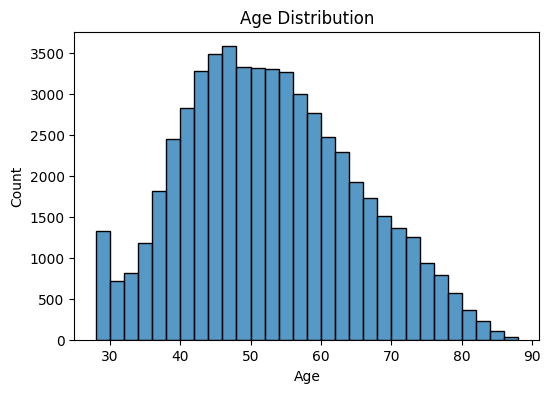

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

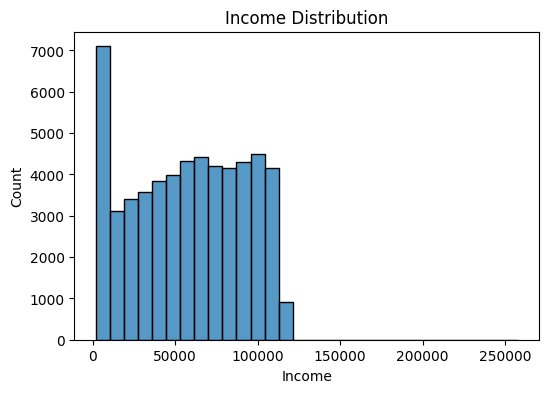

In [10]:
# Income distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Income'], bins=30)
plt.title("Income Distribution")
plt.show()

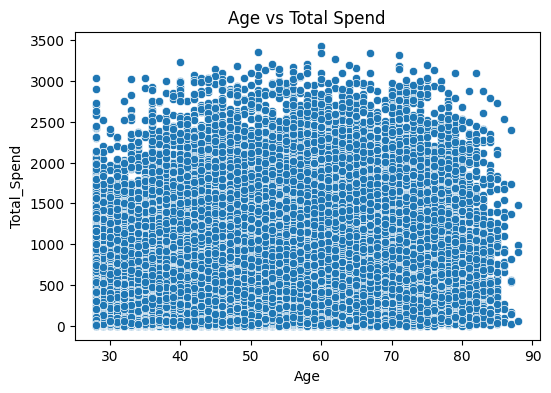

In [11]:
# Total Spend vs Age
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Age'], y=df['Total_Spend'])
plt.title("Age vs Total Spend")
plt.show()

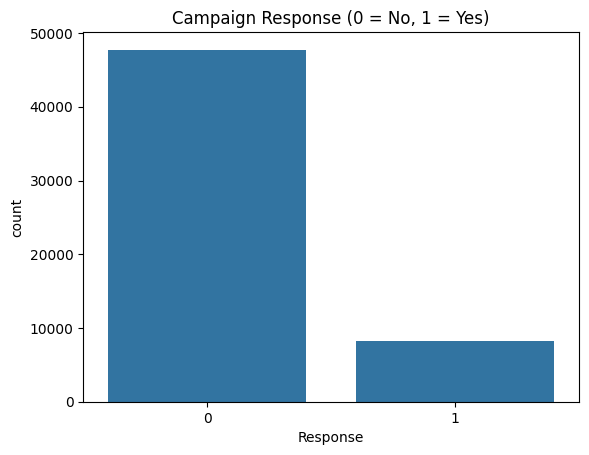

In [12]:
# Campaign response count
sns.countplot(x=df['Response'])
plt.title("Campaign Response (0 = No, 1 = Yes)")
plt.show()

In [13]:
# High Income
df['High_Income'] = df['Income'] > 75000

# Young Customer
df['Young'] = df['Age'] < 30

# Campaign Responder
df['Responder'] = df['Response'] == 1

# High Web Engagement
df['High_Web_Engagement'] = df['NumWebVisitsMonth'] > 5

# Family Customer
df['Family'] = df['Children'] > 0

# High Spender (top 10%)
threshold = df['Total_Spend'].quantile(0.90)
df['High_Spender'] = df['Total_Spend'] > threshold

In [14]:
# Check segmentation counts
df[['High_Income', 'Young', 'Responder', 
    'High_Web_Engagement', 'Family', 'High_Spender']].sum()

High_Income            19782
Young                   1325
Responder               8265
High_Web_Engagement    29970
Family                 38222
High_Spender            5599
dtype: int64

In [2]:
import pandas as pd
import sqlite3

# Load data
df = pd.read_csv('../data/marketing_campaign_data.csv')

# Connect to DB
conn = sqlite3.connect('../database.db')

# Insert into SQL table
df.to_sql('customers', conn, if_exists='replace', index=False)

print("Data inserted successfully!")

conn.close()

Data inserted successfully!


In [3]:
conn = sqlite3.connect('../database.db')
pd.read_sql("SELECT COUNT(*) FROM customers", conn)

,COUNT(*)
0,56000
